In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay
)

os.makedirs(
    "../Outputs/Notebook_09",
    exist_ok=True
)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


## Load Similarity Scores

In [2]:
genuine_scores = pd.read_csv(
    "../Outputs/Notebook_07/genuine_scores.csv"
)["Genuine_Score"].values

impostor_scores = pd.read_csv(
    "../Outputs/Notebook_07/impostor_scores.csv"
)["Impostor_Score"].values

threshold = pd.read_csv(
    "../Outputs/Notebook_07/threshold.csv"
)["Threshold"][0]

print("Threshold =", threshold)

print("Genuine Samples :", len(genuine_scores))
print("Impostor Samples :", len(impostor_scores))

Threshold = 0.1657216720572204
Genuine Samples : 1000
Impostor Samples : 1000


## Authentication Prediction

In [3]:
genuine_prediction = (
    genuine_scores >= threshold
)

impostor_prediction = (
    impostor_scores >= threshold
)

TP = np.sum(genuine_prediction)

FN = len(genuine_scores) - TP

FP = np.sum(impostor_prediction)

TN = len(impostor_scores) - FP

print("TP =", TP)
print("FN =", FN)
print("TN =", TN)
print("FP =", FP)

TP = 650
FN = 350
TN = 717
FP = 283


## Performance Metrics

In [4]:
accuracy = (

    TP + TN

) / (

    TP + TN + FP + FN

)

precision = (

    TP

) / (

    TP + FP

)

recall = (

    TP

) / (

    TP + FN

)

f1_score = (

    2 * precision * recall

) / (

    precision + recall

)

far = (

    FP

) / (

    FP + TN

)

frr = (

    FN

) / (

    TP + FN

)

eer = (

    far + frr

) / 2

## Display Authentication Results

In [5]:
print("Authentication Performance")

print("-" * 40)

print("Accuracy  :", accuracy * 100)

print("Precision :", precision)

print("Recall    :", recall)

print("F1 Score  :", f1_score)

print("FAR       :", far)

print("FRR       :", frr)

print("Approx. EER :", eer)

Authentication Performance
----------------------------------------
Accuracy  : 68.35
Precision : 0.6966773847802786
Recall    : 0.65
F1 Score  : 0.6725297465080187
FAR       : 0.283
FRR       : 0.35
Approx. EER : 0.3165


## Save Performance Metrics

In [6]:
performance_results = pd.DataFrame({

    "Metric":[

        "Accuracy",

        "Precision",

        "Recall",

        "F1 Score",

        "FAR",

        "FRR",

        "Approximate EER"

    ],

    "Value":[

        accuracy,

        precision,

        recall,

        f1_score,

        far,

        frr,

        eer

    ]

})

performance_results.to_csv(

    "../Outputs/Notebook_09/performance_metrics.csv",

    index=False

)

print("Performance Metrics Saved Successfully")

Performance Metrics Saved Successfully


In [7]:
thresholds = np.linspace(
    min(min(genuine_scores), min(impostor_scores)),
    max(max(genuine_scores), max(impostor_scores)),
    200
)

accuracy_list = []
precision_list = []
recall_list = []
f1_list = []
far_list = []
frr_list = []
eer_list = []

for threshold in thresholds:

    TP = np.sum(np.array(genuine_scores) >= threshold)
    FN = np.sum(np.array(genuine_scores) < threshold)

    FP = np.sum(np.array(impostor_scores) >= threshold)
    TN = np.sum(np.array(impostor_scores) < threshold)

    accuracy = (TP + TN) / (TP + TN + FP + FN)

    precision = TP / (TP + FP) if (TP + FP) != 0 else 0

    recall = TP / (TP + FN) if (TP + FN) != 0 else 0

    f1 = (
        2 * precision * recall
    ) / (
        precision + recall
    ) if (
        precision + recall
    ) != 0 else 0

    FAR = FP / (FP + TN)
    FRR = FN / (TP + FN)

    EER = (FAR + FRR) / 2

    accuracy_list.append(accuracy)
    precision_list.append(precision)
    recall_list.append(recall)
    f1_list.append(f1)
    far_list.append(FAR)
    frr_list.append(FRR)
    eer_list.append(EER)

print("Threshold metrics calculated successfully.")

Threshold metrics calculated successfully.


# Save Threshold Performance Results

In [8]:
threshold_metrics = pd.DataFrame({

    "Threshold": thresholds,

    "Accuracy": accuracy_list,

    "Precision": precision_list,

    "Recall": recall_list,

    "F1 Score": f1_list,

    "FAR": far_list,

    "FRR": frr_list

})

threshold_metrics.to_csv(

    "../Outputs/Notebook_09/threshold_metrics.csv",

    index=False

)

print("Threshold Metrics Saved Successfully")

Threshold Metrics Saved Successfully


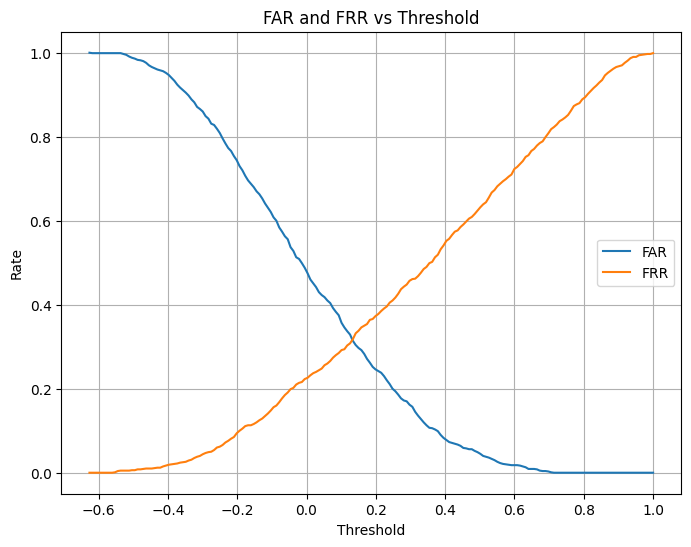

In [9]:
plt.figure(figsize=(8,6))

plt.plot(
    thresholds,
    far_list,
    label="FAR"
)

plt.plot(
    thresholds,
    frr_list,
    label="FRR"
)

plt.xlabel("Threshold")

plt.ylabel("Rate")

plt.title("FAR and FRR vs Threshold")

plt.legend()

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/FAR_FRR_vs_threshold.png"
)

plt.show()

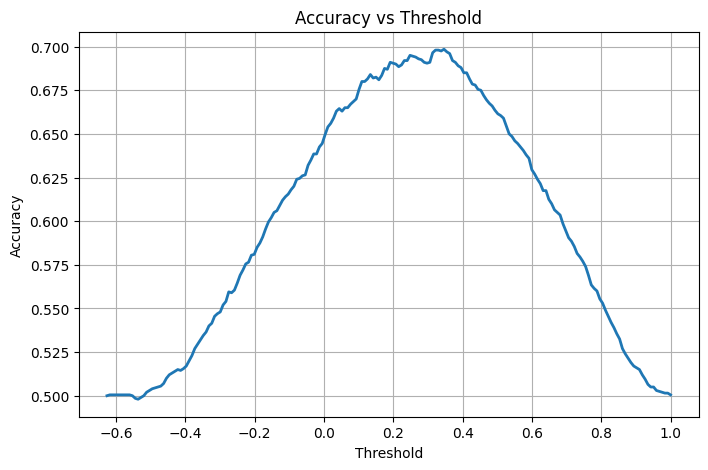

In [10]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    accuracy_list,
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Accuracy")
plt.title("Accuracy vs Threshold")

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/Accuracy_vs_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

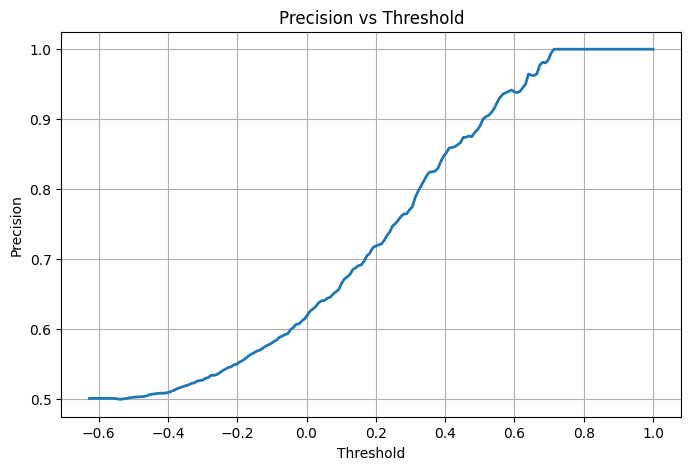

In [11]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    precision_list,
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Precision")
plt.title("Precision vs Threshold")

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/Precision_vs_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

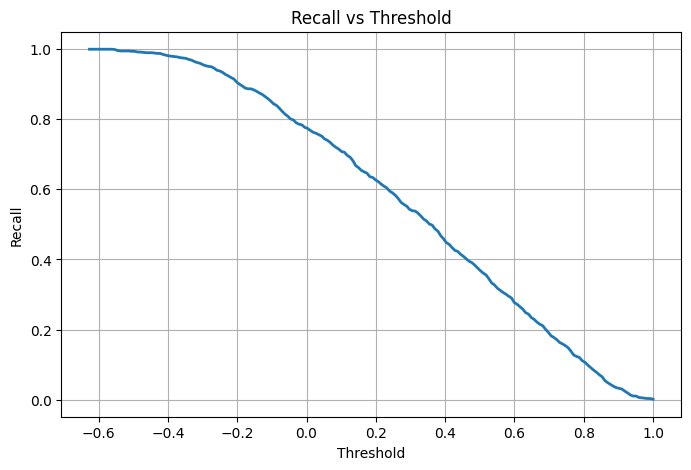

In [12]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    recall_list,
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Recall")

plt.title("Recall vs Threshold")

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/Recall_vs_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

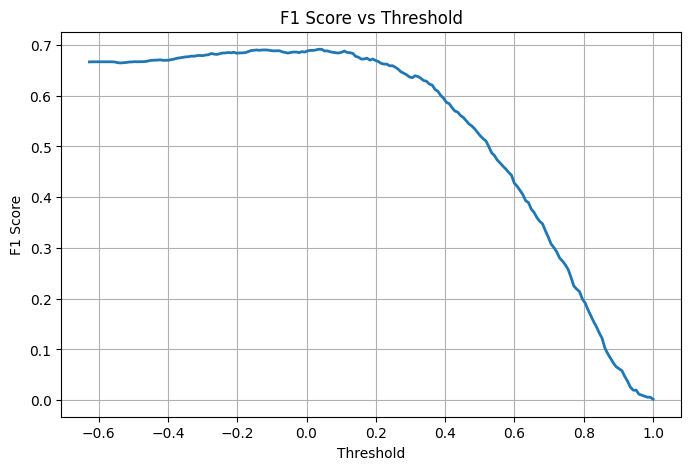

In [13]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    f1_list,
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")

plt.title("F1 Score vs Threshold")

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/F1_vs_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

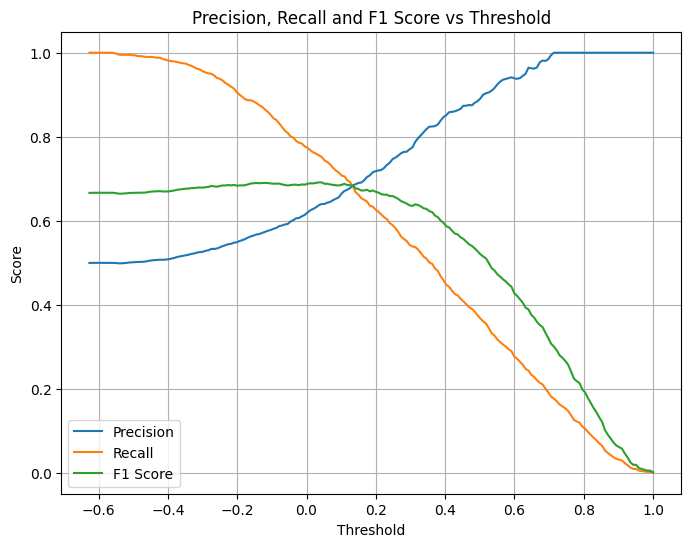

In [14]:
plt.figure(figsize=(8,6))

plt.plot(
    thresholds,
    precision_list,
    label="Precision"
)

plt.plot(
    thresholds,
    recall_list,
    label="Recall"
)

plt.plot(
    thresholds,
    f1_list,
    label="F1 Score"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Precision, Recall and F1 Score vs Threshold")

plt.legend()

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/Precision_Recall_F1_vs_threshold.png"
)

plt.show()

# Combined Metric Comparison Graph

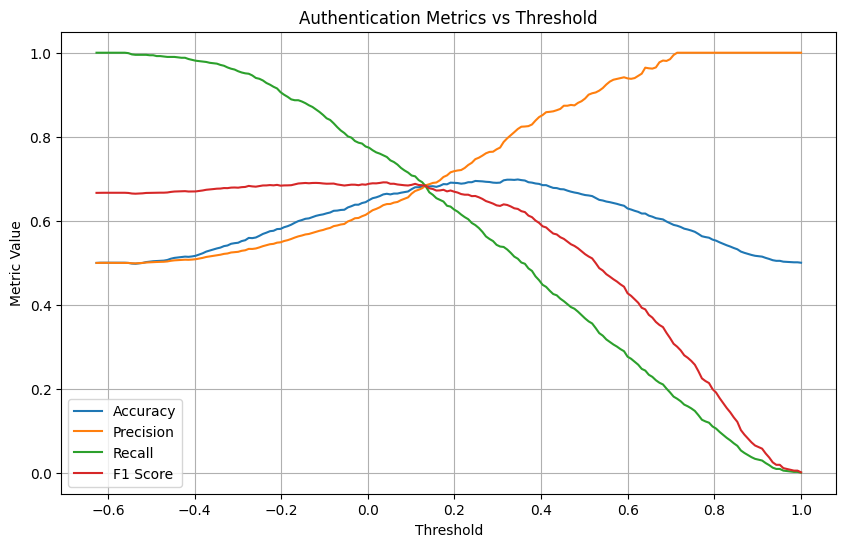

In [15]:
plt.figure(figsize=(10,6))

plt.plot(thresholds, accuracy_list, label="Accuracy")
plt.plot(thresholds, precision_list, label="Precision")
plt.plot(thresholds, recall_list, label="Recall")
plt.plot(thresholds, f1_list, label="F1 Score")

plt.xlabel("Threshold")
plt.ylabel("Metric Value")

plt.title("Authentication Metrics vs Threshold")

plt.legend()

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/all_metrics_vs_threshold.png",
    dpi=300
)

plt.show()

# FAR, FRR and EER Together

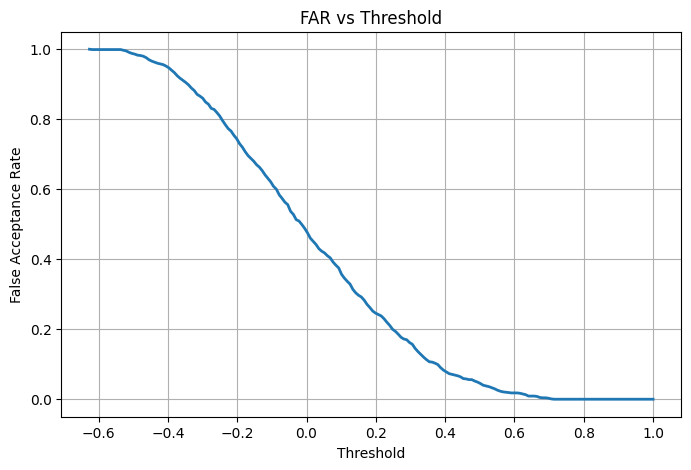

In [16]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    far_list,
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("False Acceptance Rate")

plt.title("FAR vs Threshold")

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/FAR_vs_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

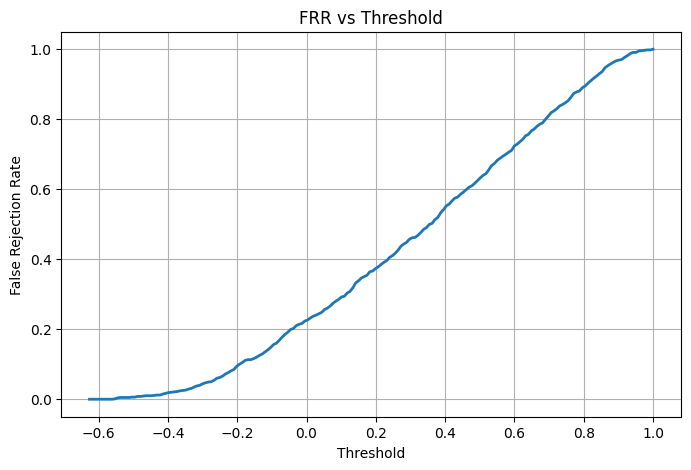

In [17]:
plt.figure(figsize=(8,5))

plt.plot(
    thresholds,
    frr_list,
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("False Rejection Rate")

plt.title("FRR vs Threshold")

plt.grid(True)

plt.savefig(
    "../Outputs/Notebook_09/FRR_vs_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

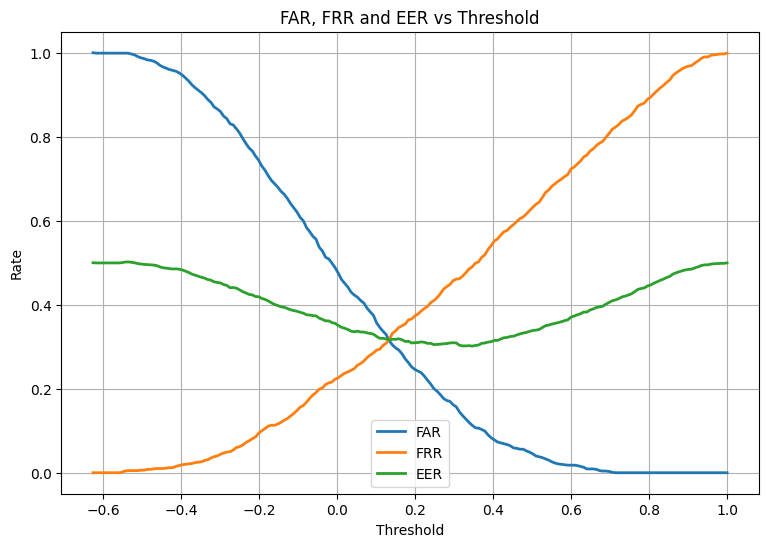

In [18]:
plt.figure(figsize=(9,6))

plt.plot(
    thresholds,
    far_list,
    label="FAR",
    linewidth=2
)

plt.plot(
    thresholds,
    frr_list,
    label="FRR",
    linewidth=2
)

plt.plot(
    thresholds,
    eer_list,
    label="EER",
    linewidth=2
)

plt.xlabel("Threshold")
plt.ylabel("Rate")

plt.title("FAR, FRR and EER vs Threshold")

plt.grid(True)

plt.legend()

plt.savefig(
    "../Outputs/Notebook_09/FAR_FRR_EER_vs_threshold.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

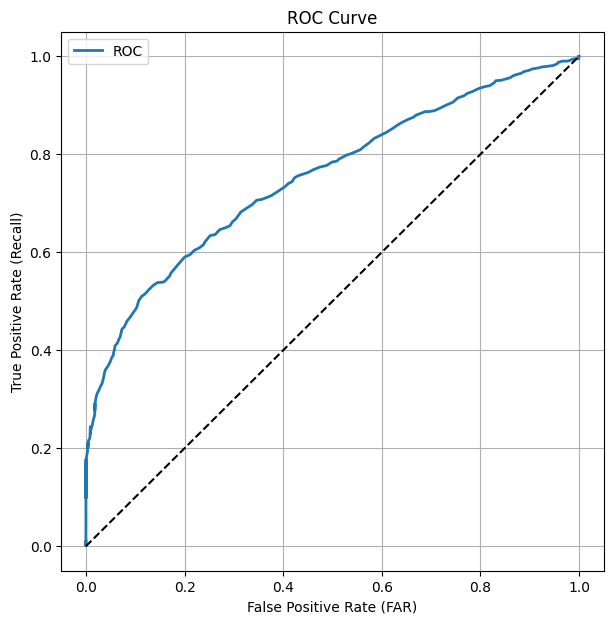

In [19]:
fpr = np.array(far_list)
tpr = np.array(recall_list)

order = np.argsort(fpr)

fpr = fpr[order]
tpr = tpr[order]

plt.figure(figsize=(7,7))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label="ROC"
)

plt.plot(
    [0,1],
    [0,1],
    '--',
    color='black'
)

plt.xlabel("False Positive Rate (FAR)")
plt.ylabel("True Positive Rate (Recall)")

plt.title("ROC Curve")

plt.grid(True)

plt.legend()

plt.savefig(
    "../Outputs/Notebook_09/ROC_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

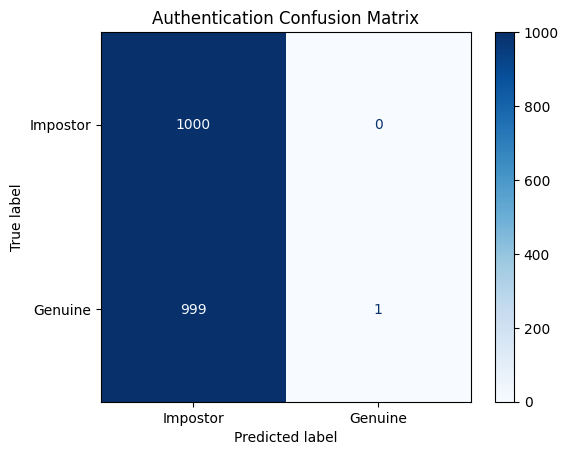

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

reported_threshold = threshold

TP = np.sum(np.array(genuine_scores) >= reported_threshold)
FN = np.sum(np.array(genuine_scores) < reported_threshold)

FP = np.sum(np.array(impostor_scores) >= reported_threshold)
TN = np.sum(np.array(impostor_scores) < reported_threshold)

cm = np.array([
    [TN, FP],
    [FN, TP]
])

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Impostor", "Genuine"]
)

disp.plot(cmap="Blues")

plt.title("Authentication Confusion Matrix")

plt.savefig(
    "../Outputs/Notebook_09/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [37]:
best_index = np.argmax(f1_list)

best_threshold = thresholds[best_index]

print("=" * 40)
print("Best Authentication Threshold")
print("=" * 40)

print(f"Best Threshold : {best_threshold:.6f}")
print(f"Accuracy       : {accuracy_list[best_index]:.4f}")
print(f"Precision      : {precision_list[best_index]:.4f}")
print(f"Recall         : {recall_list[best_index]:.4f}")
print(f"F1 Score       : {f1_list[best_index]:.4f}")
print(f"FAR            : {far_list[best_index]:.4f}")
print(f"FRR            : {frr_list[best_index]:.4f}")
print(f"EER            : {eer_list[best_index]:.4f}")

Best Authentication Threshold
Best Threshold : 0.077061
Accuracy       : 0.6735
Precision      : 0.6553
Recall         : 0.7320
F1 Score       : 0.6915
FAR            : 0.3850
FRR            : 0.2680
EER            : 0.3265


In [21]:
performance_df = pd.DataFrame({

    "Threshold": thresholds,

    "Accuracy": accuracy_list,

    "Precision": precision_list,

    "Recall": recall_list,

    "F1 Score": f1_list,

    "FAR": far_list,

    "FRR": frr_list,

    "EER": eer_list

})

performance_df.to_csv(

    "../Outputs/Notebook_09/performance_evaluation_threshold.csv",

    index=False

)

performance_df.to_csv(

    "../Outputs/Notebook_09/performance_metrics.csv",

    index=False

)

print("Threshold-wise Performance Report Saved Successfully")

Threshold-wise Performance Report Saved Successfully
